# 02 Bond Analytics

This notebook applies the Treasury benchmark curve to a small corporate bond universe and computes the main analytics used later for peer comparison and evaluated pricing.

At this stage, each bond is translated from a quoted clean price into a richer analytic record: dirty price, yield, spread to Treasury, duration, and convexity. That creates the foundation for the comp-based fair value step.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.bond_math import evaluate_bond
from src.curve import build_zero_curve, make_discount_function

In [3]:
bond_path = PROJECT_ROOT / "data" / "raw" / "bond_universe.csv"
curve_path = PROJECT_ROOT / "data" / "raw" / "treasury_curve.csv"
bonds = pd.read_csv(bond_path, parse_dates=["evaluation_date", "maturity_date"])
bonds

,bond_id,issuer,ticker,evaluation_date,maturity_date,coupon_rate,clean_price,rating,sector,seniority,currency,coupon_frequency,face_value
0,IBM_1993_625,IBM,IBM,1991-03-14,1993-06-15,0.0625,100.42,AA,Technology,Senior Unsecured,USD,2,100
1,IBM_1996_700,IBM,IBM,1991-03-14,1996-09-15,0.0700,101.18,AA,Technology,Senior Unsecured,USD,2,100
2,GE_1994_650,GE,GE,1991-03-14,1994-03-01,0.0650,100.11,AA,Industrials,Senior Unsecured,USD,2,100
3,GE_1998_725,GE,GE,1991-03-14,1998-11-15,0.0725,99.74,AA,Industrials,Senior Unsecured,USD,2,100
4,JNJ_1995_675,JNJ,JNJ,1991-03-14,1995-08-01,0.0675,100.67,AAA,Healthcare,Senior Unsecured,USD,2,100
5,JNJ_2000_740,JNJ,JNJ,1991-03-14,2000-05-15,0.0740,99.92,AAA,Healthcare,Senior Unsecured,USD,2,100
6,XOM_1997_710,XOM,XOM,1991-03-14,1997-02-15,0.0710,100.23,AA,Energy,Senior Unsecured,USD,2,100
7,XOM_2001_760,XOM,XOM,1991-03-14,2001-12-01,0.0760,99.35,AA,Energy,Senior Unsecured,USD,2,100


In [4]:
eval_date = bonds.iloc[0]["evaluation_date"]
_, zero_curve = build_zero_curve(curve_path, eval_date=eval_date)
discount_fn, _ = make_discount_function(zero_curve)
analytics = pd.DataFrame([evaluate_bond(row, discount_fn) for _, row in bonds.iterrows()])
analytics

,bond_id,issuer,evaluation_date,maturity_date,coupon_rate,clean_price,accrued_interest,dirty_price,ytm,spread_to_curve,modified_duration,convexity,model_dirty_price
0,IBM_1993_625,IBM,1991-03-14,1993-06-15,0.0625,100.42,1.528159,101.948159,0.060409,-0.009434,2.047569,5.375388,101.948159
1,IBM_1996_700,IBM,1991-03-14,1996-09-15,0.0700,101.18,3.480663,104.660663,0.067324,-0.009468,4.368741,23.948956,104.660663
2,GE_1994_650,GE,1991-03-14,1994-03-01,0.0650,100.11,0.229620,100.339620,0.064553,-0.007052,2.653667,8.672639,100.339620
3,GE_1998_725,GE,1991-03-14,1998-11-15,0.0725,99.74,2.383287,102.123287,0.072895,-0.005841,5.672023,40.925557,102.123287
4,JNJ_1995_675,JNJ,1991-03-14,1995-08-01,0.0675,100.67,0.764503,101.434503,0.065740,-0.008968,3.718948,16.825745,101.434503
5,JNJ_2000_740,JNJ,1991-03-14,2000-05-15,0.0740,99.92,2.432597,102.352597,0.074089,-0.005196,6.420340,53.618617,102.352597
6,XOM_1997_710,XOM,1991-03-14,1997-02-15,0.0710,100.23,0.529558,100.759558,0.070487,-0.006754,4.748888,27.625423,100.759558
7,XOM_2001_760,XOM,1991-03-14,2001-12-01,0.0760,99.35,2.150549,101.500549,0.076864,-0.001546,7.079663,66.815752,101.500549


In [5]:
analytics_display = analytics[["bond_id", "dirty_price", "ytm", "spread_to_curve", "modified_duration", "convexity"]].copy()
for col in ["ytm", "spread_to_curve"]:
    analytics_display[col] = analytics_display[col] * 100
analytics_display

,bond_id,dirty_price,ytm,spread_to_curve,modified_duration,convexity
0,IBM_1993_625,101.948159,6.040946,-0.943413,2.047569,5.375388
1,IBM_1996_700,104.660663,6.732443,-0.946844,4.368741,23.948956
2,GE_1994_650,100.339620,6.455330,-0.705169,2.653667,8.672639
3,GE_1998_725,102.123287,7.289502,-0.584139,5.672023,40.925557
4,JNJ_1995_675,101.434503,6.574015,-0.896818,3.718948,16.825745
5,JNJ_2000_740,102.352597,7.408870,-0.519640,6.420340,53.618617
6,XOM_1997_710,100.759558,7.048727,-0.675382,4.748888,27.625423
7,XOM_2001_760,101.500549,7.686436,-0.154645,7.079663,66.815752


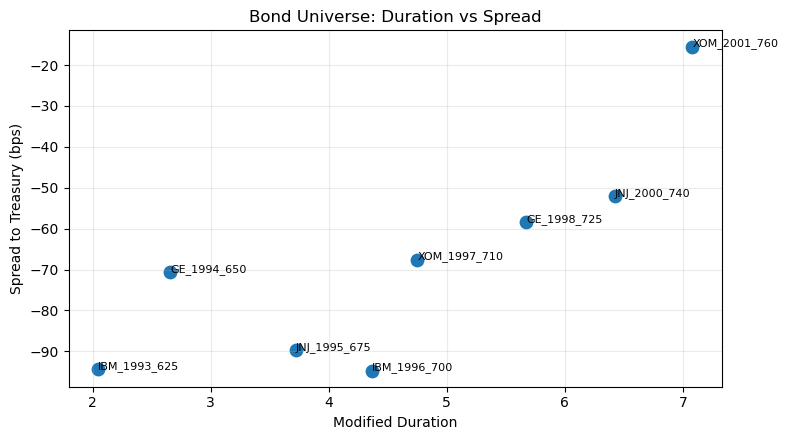

In [6]:
plt.figure(figsize=(8, 4.5))
plt.scatter(analytics["modified_duration"], analytics["spread_to_curve"] * 10000, s=80)
for row in analytics.itertuples(index=False):
    plt.annotate(row.bond_id, (row.modified_duration, row.spread_to_curve * 10000), fontsize=8)
plt.xlabel("Modified Duration")
plt.ylabel("Spread to Treasury (bps)")
plt.title("Bond Universe: Duration vs Spread")
plt.grid(alpha=0.25)
plt.tight_layout()

These results make it easier to compare bonds on a like-for-like basis. Even in this small sample, the spread and duration profile already hints at which names are likely to make sense as peers and which bonds may stand out later in the exception review.